In [1]:
import os
import gc
import zarr
import yaml
import json
import numba
import numpy as np
import polars as pl
import pandas as pd
from tqdm import tqdm
import statsmodels.api as sm

from plotnine import *
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors


# Single gene-trait association plots

In [16]:
## Single gene-trait association plot
gene_name = 'LDLR'
phenotype = 'apolipoprotein_b_int'

In [17]:
# Configuration and paths
eur_samples_path = '/home/dnanexus/data_dir/unrelated_cauc_samples_3rd_degree.csv'
mac = 100

maf=1e-3
n = !wc -l $eur_samples_path
n_eur = int(n[0].split(' ')[0])
mac = maf*(2*n_eur)
mac
config_path = "/home/dnanexus/ukbgym/config_wgs.yaml"
with open(config_path) as f:
    config = yaml.safe_load(f)

# Use a list comprehension to flatten the nested dictionary into records
records = [
    {
        "category": category,
        "annotation": anno,
        "color": props["color"],
        "label": props["label"],
        "annotation_dir": props.get("direction", 1),
    }
    for category, annos in config["rare_variant_annotations"].items()
    for anno, props in annos.items()
]

# Create the DataFrame directly from the list of records
anno_config_df = pl.DataFrame(records)
all_annotation_list = anno_config_df.select(pl.col("annotation")).to_series().to_list()
anno_config_df

category,annotation,color,label,annotation_dir
str,str,str,str,i64
"""genetic_diversity""","""cadd_raw""","""#1f77b4""","""CADD Raw""",1
"""missense""","""am_pathogenicity""","""#e76e5b""","""AlphaMissense""",1
"""missense""","""esmscoremissense""","""#feb72d""","""ESM1v""",-1
"""conservation""","""gpn_score""","""#942c80""","""GPN-MSA""",-1
"""conservation""","""zooverphylop""","""#6a1c81""","""Zoonomia vertebrate PhyloP""",1
…,…,…,…,…
"""regulatory""","""promoterai_abs""","""#00A99D""","""PromoterAI abs""",1
"""regulatory""","""promoterai_under""","""#00A99D""","""PromoterAI under""",-1
"""regulatory""","""promoterai_over""","""#00A99D""","""PromoterAI over""",1


In [18]:
exp_data = pl.read_csv('/home/dnanexus/data_dir/exp_data/kircher_all_enhancers_and_promoters.tsv', separator='\t').drop(['pos']).rename({
    'locus': 'gene_name',
    'Chromosome': 'chrom',
    'variant_pos': 'pos',
}).with_columns(
    id = pl.col("chrom") + ":" + pl.col("pos").cast(pl.Utf8) + ":" + pl.col("ref") + ":" + pl.col("alt"),
)#.select(['id', 'gene_name', 'log2FC'])

exp_data#['gene_name'].value_counts(sort=True).head(10)

chrom,pos,ref,alt,log2FC,Variance,gene_name,var_id,abs_log2FC,is_enhancer,id
str,i64,str,str,f64,f64,str,str,f64,bool,str
"""chr11""",5227038,"""T""","""C""",0.02,0.01,"""HBB""","""11_5227038_T_C_HBB""",0.02,false,"""chr11:5227038:T:C"""
"""chr11""",5227038,"""T""","""G""",-0.03,0.0,"""HBB""","""11_5227038_T_G_HBB""",0.03,false,"""chr11:5227038:T:G"""
"""chr11""",5227039,"""G""","""A""",-0.16,0.17,"""HBB""","""11_5227039_G_A_HBB""",0.16,false,"""chr11:5227039:G:A"""
"""chr11""",5227039,"""G""","""C""",0.02,0.01,"""HBB""","""11_5227039_G_C_HBB""",0.02,false,"""chr11:5227039:G:C"""
"""chr11""",5227039,"""G""","""T""",-0.05,0.01,"""HBB""","""11_5227039_G_T_HBB""",0.05,false,"""chr11:5227039:G:T"""
…,…,…,…,…,…,…,…,…,…,…
"""chr10""",46046261,"""G""","""T""",0.05,0.04,"""MSMB""","""10_46046261_G_T_MSMB""",0.05,false,"""chr10:46046261:G:T"""
"""chr10""",46046261,"""G""","""C""",0.08,0.03,"""MSMB""","""10_46046261_G_C_MSMB""",0.08,false,"""chr10:46046261:G:C"""
"""chr10""",46046260,"""A""","""T""",-0.01,0.0,"""MSMB""","""10_46046260_A_T_MSMB""",0.01,false,"""chr10:46046260:A:T"""


In [19]:
anno = pl.scan_parquet(f"/home/dnanexus/data_dir/genebass1e6_genes_10kb_allvars_annotated_250925.parquet").filter(pl.col('gene_name') == gene_name).collect(engine='streaming')

existing_annos = [c for c in all_annotation_list if c in anno.collect_schema().names()]

anno = (
    anno
    .select(
        set(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']).union(set(existing_annos))
    )
)
anno

promoterai_abs,relative_cds_position,TSS,cadd_raw,dist_to_tss,Strand,id,zooverphylop,abexp_min,promoterai_under,gene_length,esmscoremissense,delta_score,absplice_dna_max,promoterai,abexp_max,verphylop,pangolin_score,gpn_score,region,absplice2_max,promoterai_over,gene_name,am_pathogenicity
f32,f32,i64,f32,i64,cat,str,f32,f64,f32,i64,f32,f32,f32,f32,f64,f32,f32,f32,str,f32,f32,str,f32
0.0,0.0,11089461,0.372048,4277,"""+""","""chr19:11093738:G:A""",-0.12,-0.005877,0.0,44360,0.0,0.0,0.001,0.0,-0.005501,-0.141,0.0,0.05,"""ENSG00000130164""",0.000033,0.0,"""LDLR""",0.0
0.0,0.0,11089461,-0.889739,21488,"""+""","""chr19:11110949:G:A""",-2.853,-0.005877,0.0,44360,0.0,0.0,0.001,0.0,-0.005501,-1.677,0.0,-0.87,"""ENSG00000130164""",0.000033,0.0,"""LDLR""",0.0
0.0,0.0,11089461,-0.0706,48226,"""+""","""chr19:11137687:A:C""",-1.109,0.002093,0.0,44360,0.0,0.0,0.0,0.0,0.002469,-1.413,0.0,0.18,"""ENSG00000130164""",0.0,0.0,"""LDLR""",0.0
0.0,0.0,11089461,-0.358473,42447,"""+""","""chr19:11131908:T:C""",-1.837,-0.005605,0.0,44360,0.0,0.0,0.001,0.0,-0.005229,-2.955,0.0,-1.16,"""ENSG00000130164""",0.000033,0.0,"""LDLR""",0.0
0.0,0.0,11089461,-0.016461,10209,"""+""","""chr19:11099670:C:G""",-0.848,-0.005877,0.0,44360,0.0,0.0,0.001,0.0,-0.005501,0.365,0.0,-1.39,"""ENSG00000130164""",0.000033,0.0,"""LDLR""",0.0
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
0.0,0.0,11089461,0.0,31791,"""+""","""chr19:11121252:TGAGGATTG:T""",-0.146,null,0.0,44360,0.0,0.0,0.0,0.0,null,0.042,0.0,-1.46,"""ENSG00000130164""",0.0,0.0,"""LDLR""",0.0
0.0,0.0,11089461,0.0,-4494,"""+""","""chr19:11084967:C:CAAAAAACA""",-0.146,null,0.0,44360,0.0,0.0,0.0,0.0,null,0.042,0.0,-1.46,"""ENSG00000130164""",0.0,0.0,"""LDLR""",0.0
0.0,0.0,11089461,0.0,7596,"""+""","""chr19:11097057:ATT:A""",-0.146,null,0.0,44360,0.0,0.0,0.0,0.0,null,0.042,0.0,-1.46,"""ENSG00000130164""",0.0,0.0,"""LDLR""",0.0


In [20]:
melted_anno = anno.unpivot(
    index=["id", "region"],
    on=existing_annos,
    variable_name="annotation",
    value_name="annotation_score"
).with_columns(
    pl.col("annotation_score").cast(pl.Float32),
    pl.col("region").cast(pl.Utf8),
)
melted_anno

id,region,annotation,annotation_score
str,str,str,f32
"""chr19:11093738:G:A""","""ENSG00000130164""","""cadd_raw""",0.372048
"""chr19:11110949:G:A""","""ENSG00000130164""","""cadd_raw""",-0.889739
"""chr19:11137687:A:C""","""ENSG00000130164""","""cadd_raw""",-0.0706
"""chr19:11131908:T:C""","""ENSG00000130164""","""cadd_raw""",-0.358473
"""chr19:11099670:C:G""","""ENSG00000130164""","""cadd_raw""",-0.016461
…,…,…,…
"""chr19:11121252:TGAGGATTG:T""","""ENSG00000130164""","""abexp_max""",null
"""chr19:11084967:C:CAAAAAACA""","""ENSG00000130164""","""abexp_max""",null
"""chr19:11097057:ATT:A""","""ENSG00000130164""","""abexp_max""",null


In [21]:
# Get phenotype data for the phenotype of interest
appv = pl.scan_parquet("/home/dnanexus/data_dir/appv_files/avg_pheno_per_var_quantitative_EUR_genebass1e6_PRScorr.parquet").filter(pl.col('phenotype') == phenotype).collect(engine='streaming')

# Create a lazy frame with the unique keys
anno_keys = anno.select(pl.col('id').unique())

# Chain the filter and the much faster semi join
appv = (
    appv
    .join(
        anno_keys, on='id', how='semi'
    )
    .filter(
        pl.col('n_individuals') <= mac
    )
)

# Merge phenotype data and annotation data
pg_df = (
    appv
    .join(
        melted_anno, 
        on="id", 
        how="inner"
    )
    .join(
        anno.select(['id', 'region', 'TSS', 'Strand', 'gene_length', 'gene_name', 'dist_to_tss']), 
        on=['id', 'region'], 
        how='inner'
    )
)

# Join with experimental data
pg_df = pg_df.join(exp_data.filter(pl.col('gene_name') == gene_name), on='id', how='inner')
pg_df

id,phenotype,n_individuals,mean_pheno_value,std_pheno_value,region,annotation,annotation_score,TSS,Strand,gene_length,gene_name,dist_to_tss,chrom,pos,ref,alt,log2FC,Variance,gene_name_right,var_id,abs_log2FC,is_enhancer
str,str,u32,f32,f32,str,str,f32,i64,cat,i64,str,i64,str,i64,str,str,f64,f64,str,str,f64,bool
"""chr19:11089498:C:T""","""apolipoprotein_b_int""",1,0.413114,null,"""ENSG00000130164""","""cadd_raw""",0.7626,11089461,"""+""",44360,"""LDLR""",37,"""chr19""",11089498,"""C""","""T""",-0.15,0.23,"""LDLR""","""19_11089498_C_T_LDLR""",0.15,false
"""chr19:11089493:T:C""","""apolipoprotein_b_int""",6,-0.105539,0.906354,"""ENSG00000130164""","""cadd_raw""",-0.26411,11089461,"""+""",44360,"""LDLR""",32,"""chr19""",11089493,"""T""","""C""",-0.09,0.08,"""LDLR""","""19_11089493_T_C_LDLR""",0.09,false
"""chr19:11089524:A:T""","""apolipoprotein_b_int""",1,0.277587,null,"""ENSG00000130164""","""cadd_raw""",0.935437,11089461,"""+""",44360,"""LDLR""",63,"""chr19""",11089524,"""A""","""T""",-0.02,0.0,"""LDLR""","""19_11089524_A_T_LDLR""",0.02,false
"""chr19:11089365:T:C""","""apolipoprotein_b_int""",1,0.97311,null,"""ENSG00000130164""","""cadd_raw""",0.310214,11089461,"""+""",44360,"""LDLR""",-96,"""chr19""",11089365,"""T""","""C""",0.24,0.56,"""LDLR""","""19_11089365_T_C_LDLR""",0.24,false
"""chr19:11089474:G:A""","""apolipoprotein_b_int""",1,0.075235,null,"""ENSG00000130164""","""cadd_raw""",0.648609,11089461,"""+""",44360,"""LDLR""",13,"""chr19""",11089474,"""G""","""A""",0.89,1.0,"""LDLR""","""19_11089474_G_A_LDLR""",0.89,false
…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…,…
"""chr19:11089526:A:C""","""apolipoprotein_b_int""",34,0.274444,0.924073,"""ENSG00000130164""","""abexp_max""",-0.012365,11089461,"""+""",44360,"""LDLR""",65,"""chr19""",11089526,"""A""","""C""",0.1,0.01,"""LDLR""","""19_11089526_A_C_LDLR""",0.1,false
"""chr19:11089371:T:G""","""apolipoprotein_b_int""",3,0.610538,1.573816,"""ENSG00000130164""","""abexp_max""",-0.011976,11089461,"""+""",44360,"""LDLR""",-90,"""chr19""",11089371,"""T""","""G""",-0.56,0.45,"""LDLR""","""19_11089371_T_G_LDLR""",0.56,false
"""chr19:11089264:A:C""","""apolipoprotein_b_int""",2,-0.242079,0.824921,"""ENSG00000130164""","""abexp_max""",0.002469,11089461,"""+""",44360,"""LDLR""",-197,"""chr19""",11089264,"""A""","""C""",0.05,0.01,"""LDLR""","""19_11089264_A_C_LDLR""",0.05,false


In [22]:
pg_df['annotation'].value_counts(sort=True)

annotation,count
str,u64
"""cadd_raw""",69
"""am_pathogenicity""",69
"""esmscoremissense""",69
"""gpn_score""",69
"""zooverphylop""",69
…,…
"""promoterai_abs""",69
"""promoterai_under""",69
"""promoterai_over""",69


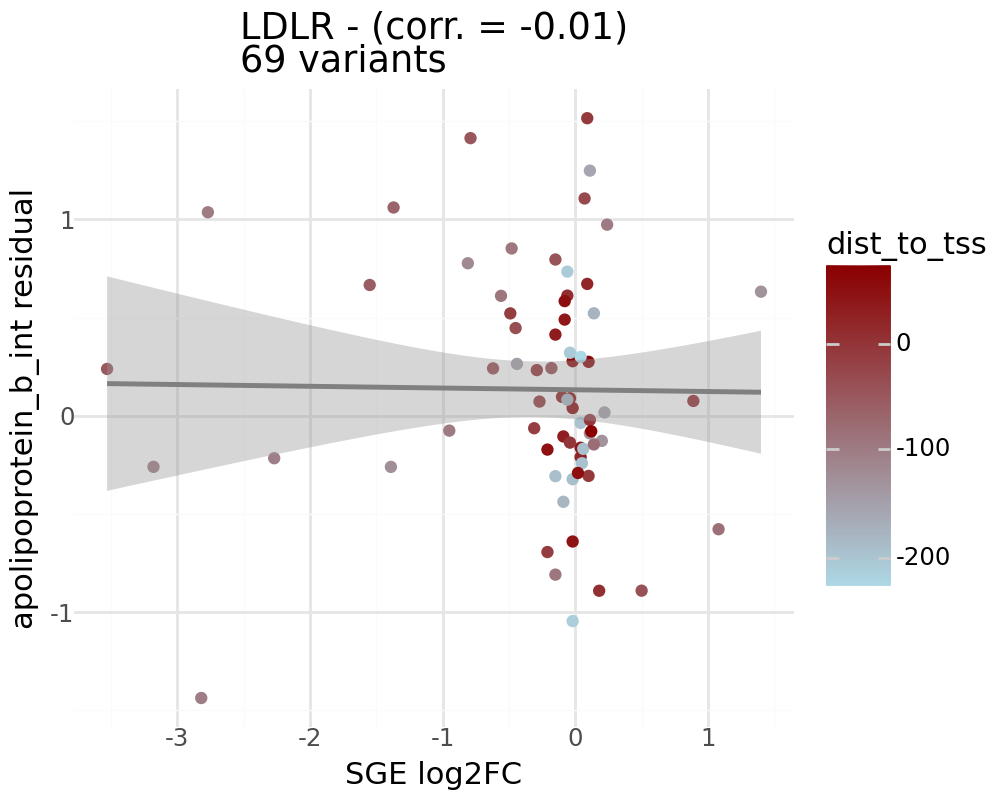

In [31]:
plot_df = (
    pg_df[['id', 'n_individuals', 'dist_to_tss', 'mean_pheno_value', 'log2FC']]
    .unique()
    # .filter(
    #     # (pl.col('log2FC') < -0.1)
    #     (pl.col('log2FC') > 0.1)
    # )
)

(
    ggplot(plot_df, aes(x='log2FC', y='mean_pheno_value', color='dist_to_tss')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x="SGE log2FC",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('log2FC', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

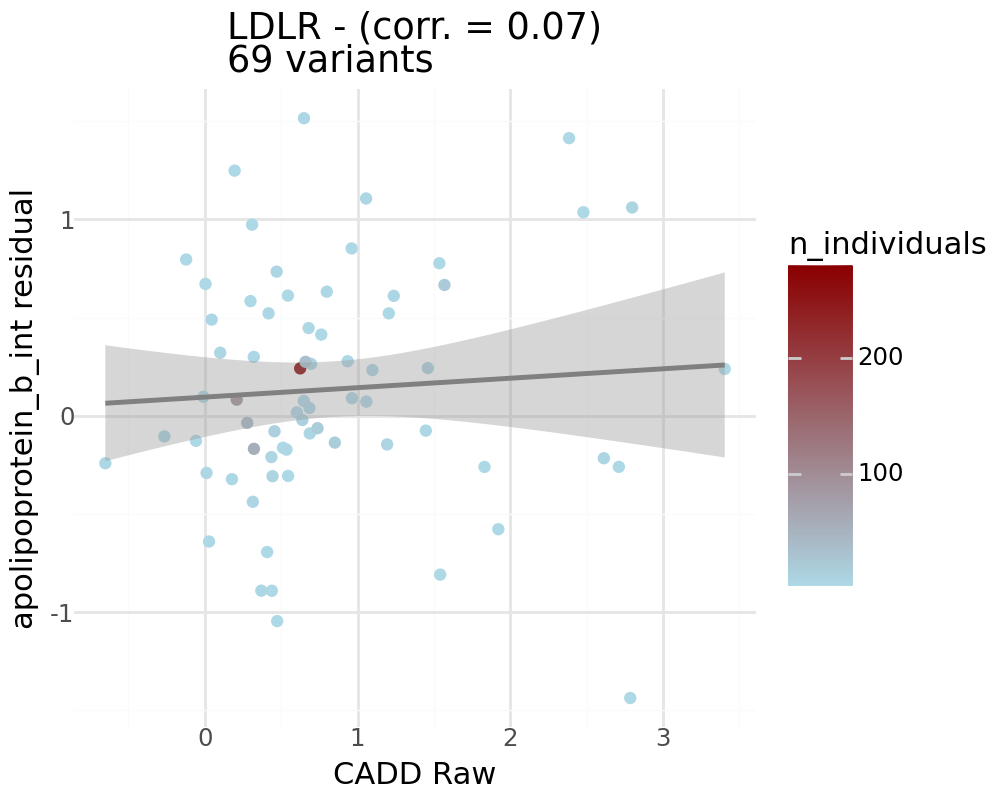

In [24]:
annotation = 'cadd_raw'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

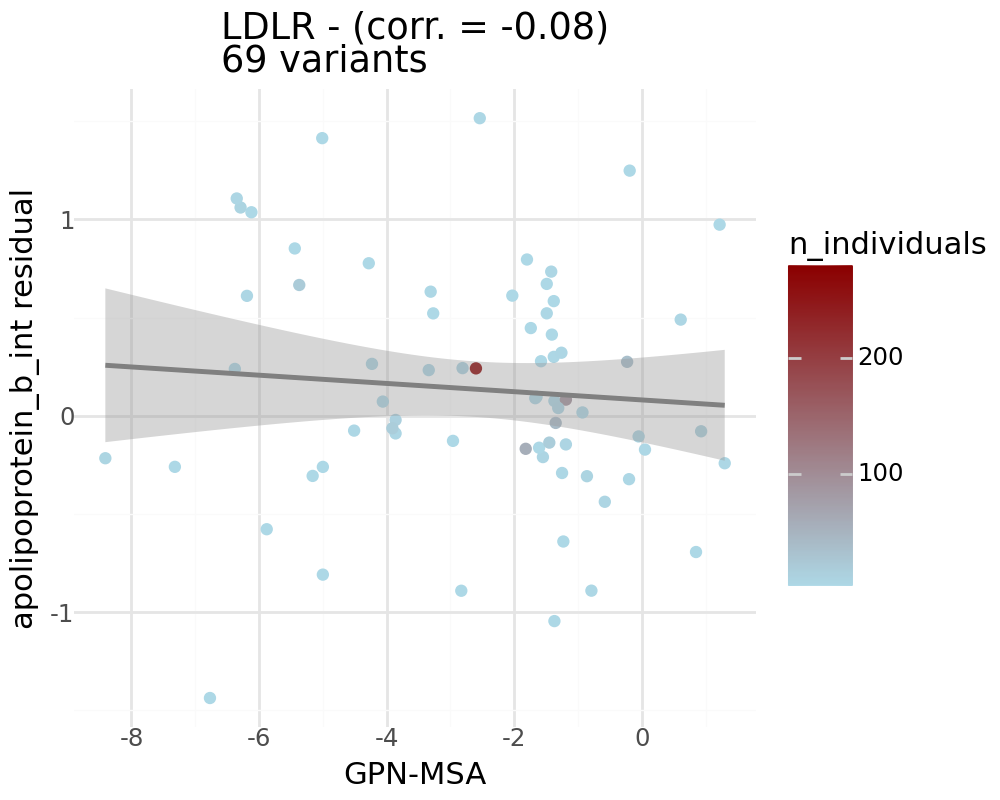

In [25]:
annotation = 'gpn_score'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

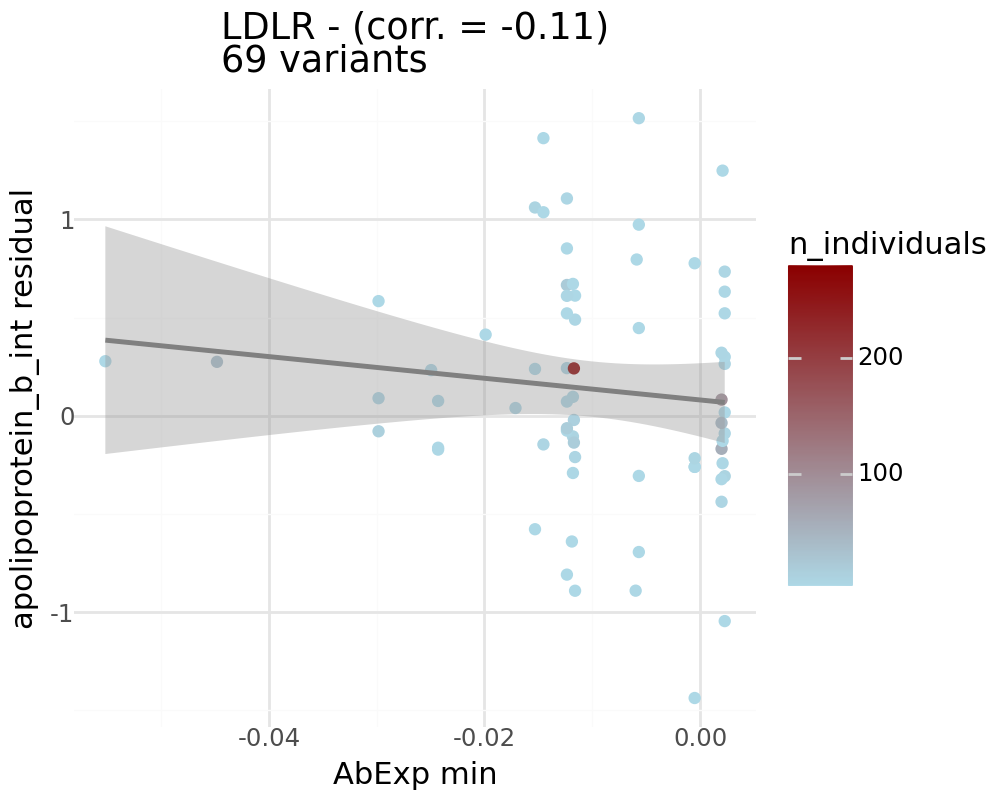

In [26]:
annotation = 'abexp_min'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)

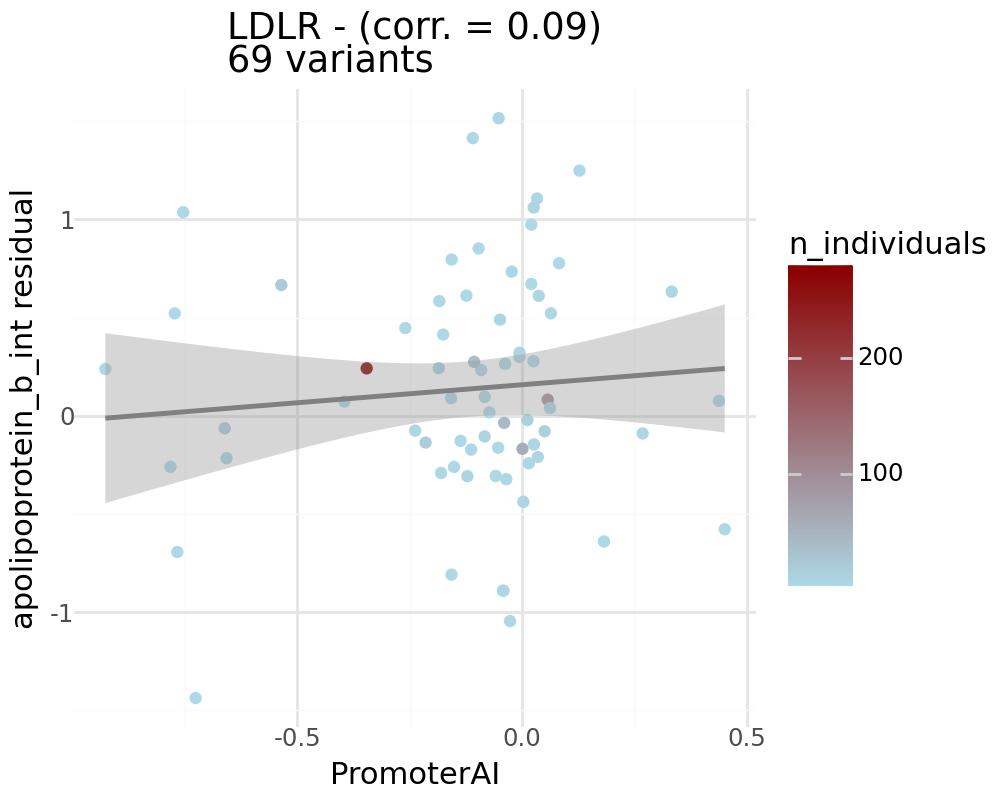

In [27]:
annotation = 'promoterai'
anno_label = anno_config_df.filter(pl.col('annotation') == annotation)['label'].item()

plot_df = (
    pg_df
    .filter(
        # (pl.col('dist_to_tss') >= -50) &
        # (pl.col('dist_to_tss') <= 0) &
        (pl.col('annotation') == annotation)
    )
)

(
    ggplot(plot_df, aes(x='annotation_score', y='mean_pheno_value', color='n_individuals')) +
    geom_point(alpha=1) +
    geom_smooth(method='lm', se=True, color='gray') +
    scale_color_gradient(low='lightblue', high='darkred') +
    theme_minimal() +
    labs(
        x=f"{anno_label}",
        y=f"{phenotype} residual",
        title=f"{gene_name} - (corr. = {plot_df.select(pl.corr('annotation_score', 'mean_pheno_value')).to_series()[0]:.2f})\n{plot_df.shape[0]} variants"
    ) +
    theme(figure_size=(5, 4))
)